In [1]:
import os
import sys

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Ensure notebook can import local packages from project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
from tqdm import tqdm
from PIL import Image
from torchvision import transforms

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer

from inference import load_model_and_vocab, greedy_decode
from datasets.data_loader import get_loaders
from datasets.preprocessing import load_captions

from config import config

def run_evaluation(checkpoint_path, data_dir):
    device = config.DEVICE
    
    # 1. Load Model & Vocab
    model, vocab = load_model_and_vocab(checkpoint_path, data_dir, device)
    model.eval()

    # 2. Lấy DataLoader tập Test chuẩn từ config
    print("Đang chuẩn bị dữ liệu tập Test (70/15/15 split)...")
    (train_loader, val_loader, test_loader), _, (n_train, n_val, n_test) = get_loaders(
        data_dir,
        split_dir=config.SPLIT_DIR,
        train_split=config.TRAIN_SPLIT,
        val_split=config.VAL_SPLIT,
        test_split=config.TEST_SPLIT,
        seed=config.SEED,
        batch_size=config.BATCH_SIZE,
        vocab=vocab # Dùng vocab đã load từ checkpoint
    )
    
    print(f"Số lượng ảnh tập Test: {n_test} ảnh.")

    gts = {}
    res = {}
    
    # Để tính CIDEr/BLEU chuẩn COCO, ta cần tất cả Ground Truth của từng ảnh
    # Ta load lại captions_dict để lấy đủ 5 câu/ảnh
    all_captions = load_captions(os.path.join(data_dir, "captions.txt"))
    
    # Lấy danh sách image_paths từ test_dataset
    test_dataset = test_loader.dataset
    
    print(f"Đang chạy inference trên {len(test_dataset)} mẫu (captions)...")
    # Lưu ý: test_dataset có thể chứa nhiều entry cho cùng 1 ảnh nếu ta phẳng hóa.
    # Nhưng ở bước evaluation này, ta chỉ cần chạy 1 lần cho mỗi ảnh.
    
    processed_images = set()
    
    with torch.no_grad():
        for i in tqdm(range(len(test_dataset))):
            img_path = test_dataset.image_paths[i]
            img_name = os.path.basename(img_path)
            
            if img_name in processed_images:
                continue
            
            processed_images.add(img_name)
            img_id = img_name
            
            # Ground Truth
            gts[img_id] = [{"caption": c} for c in all_captions[img_name]]
            
            # Prediction
            img_tensor, _ = test_dataset[i]
            img_tensor = img_tensor.unsqueeze(0).to(device)
            
            generated_cap = greedy_decode(model, img_tensor, vocab, device=device)
            res[img_id] = [{"caption": generated_cap}]

    # 3. Tokenize (Chuẩn COCO)
    print("Tokenizing...")
    tokenizer = PTBTokenizer()
    gts = tokenizer.tokenize(gts)
    res = tokenizer.tokenize(res)

    # 4. Tính toán các chỉ số
    print("Đang tính toán các chỉ số...")
    scorers = [
        (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
        # (Meteor(), "METEOR"), 
        (Rouge(), "ROUGE_L"),
        (Cider(), "CIDEr")
    ]

    final_scores = {}
    for scorer, method in scorers:
        score, _ = scorer.compute_score(gts, res)
        if isinstance(method, list):
            for sc, m in zip(score, method):
                final_scores[m] = sc
        else:
            final_scores[method] = score

    # 5. In kết quả
    print("\n" + "="*40)
    print(f"KẾT QUẢ ĐÁNH GIÁ (TRÊN TẬP TEST - {len(processed_images)} ẢNH):")
    for metric, val in final_scores.items():
        print(f"{metric:<10}: {val:.4f}")
    print("="*40)

if __name__ == "__main__":
    run_evaluation(os.path.join(config.CHECKPOINT_DIR, "epoch_9.pt"), config.DATA_DIR)


Mô hình đang tải Vocabulary chuẩn...
Loading existing splits from data\splits_seed_42.json
Đang tải trọng số từ: Checkpoints\epoch_9.pt


c:\Users\ADMIN\anaconda3\envs\BaiTapFlickr8k\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\BaiTapFlickr8k\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Đang chuẩn bị dữ liệu tập Test (70/15/15 split)...
Loading existing splits from data_splits\splits_seed_42.json
Số lượng ảnh tập Test: 1215 ảnh.
Đang chạy inference trên 6075 mẫu (captions)...


100%|██████████| 6075/6075 [00:41<00:00, 145.49it/s]


Tokenizing...
Đang tính toán các chỉ số...
{'testlen': 12462, 'reflen': 12257, 'guess': [12462, 11247, 10032, 8817], 'correct': [7618, 3361, 1331, 517]}
ratio: 1.0167251366565213

KẾT QUẢ ĐÁNH GIÁ (TRÊN TẬP TEST - 1215 ẢNH):
Bleu_1    : 0.6113
Bleu_2    : 0.4274
Bleu_3    : 0.2894
Bleu_4    : 0.1942
ROUGE_L   : 0.4616
CIDEr     : 0.4781


In [ ]:
# import torch
# import os
# import argparse
# from PIL import Image
# from torchvision import transforms
# import matplotlib.pyplot as plt
# # Ensure notebook can import local packages from project root
# PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)
# from inference import load_model_and_vocab, greedy_decode

# from config import config

# def predict_single_image(image_path, checkpoint_path=None, data_dir=None):
#     device = config.DEVICE
#     checkpoint_path = checkpoint_path or os.path.join(config.CHECKPOINT_DIR, "epoch_9.pt")
#     data_dir = data_dir or config.DATA_DIR
    
#     # 1. Load Model & Vocab
#     model, vocab = load_model_and_vocab(checkpoint_path, data_dir, device)
#     model.eval()

#     # 2. Tiền xử lý ảnh
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     ])

#     if not os.path.exists(image_path):
#         print(f"LỖI: Không tìm thấy ảnh tại {image_path}")
#         return

#     img = Image.open(image_path).convert("RGB")
#     img_tensor = transform(img).unsqueeze(0).to(device)

#     # 3. Sinh Caption
#     print("Mô hình đang suy luận...")
#     caption = greedy_decode(model, img_tensor, vocab, device=device)

#     # 4. Hiển thị kết quả
#     print("\n" + "="*40)
#     print(f"ẢNH: {os.path.basename(image_path)}")
#     print(f"KẾT QUẢ: {caption}")
#     print("="*40)

#     # (Tùy chọn) Hiển thị ảnh nếu có môi trường đồ họa
#     # plt.imshow(img)
#     # plt.title(f"Predicted: {caption}")
#     # plt.axis('off')
#     # plt.show()

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(description="Dự đoán caption cho 1 ảnh đơn lẻ.")
#     parser.add_argument("--image", type=str, required=True, help="Đường dẫn tới file ảnh.")
#     parser.add_argument("--checkpoint", type=str, default="Checkpoints/epoch_9.pt", help="Đường dẫn tới checkpoint model.")
#     parser.add_argument("--data_dir", type=str, default="data", help="Thư mục chứa dữ liệu (để load vocab).")
    
#     args = parser.parse_args()

#     predict_single_image(args.image, args.checkpoint, args.data_dir)


usage: ipykernel_launcher.py [-h] --image IMAGE [--checkpoint CHECKPOINT]
                             [--data_dir DATA_DIR]
ipykernel_launcher.py: error: the following arguments are required: --image


SystemExit: 2

Mô hình đang tải Vocabulary chuẩn...
Loading existing splits from data\splits_seed_42.json
Đang tải trọng số từ: Checkpoints\epoch_9.pt


c:\Users\ADMIN\anaconda3\envs\BaiTapFlickr8k\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\BaiTapFlickr8k\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Bắt đầu phân tích XAI cho ảnh: data\Images\3420278866_1d17c12713.jpg
Ground Truth Captions:
  1. andy rodderick gets ready to hit a tennis ball .
  2. andy roddick plays tennis .
  3. a tennis player in mid game holding a racquet .
  4. man dressed in black and white holds his tennis racket up waiting for the ball .
  5. tennis player getting ready to play tennis .
Dự đoán: a tennis player is <unk> a tennis ball .
XAI result saved to: evaluation_results\xai_3420278866_1d17c12713.png


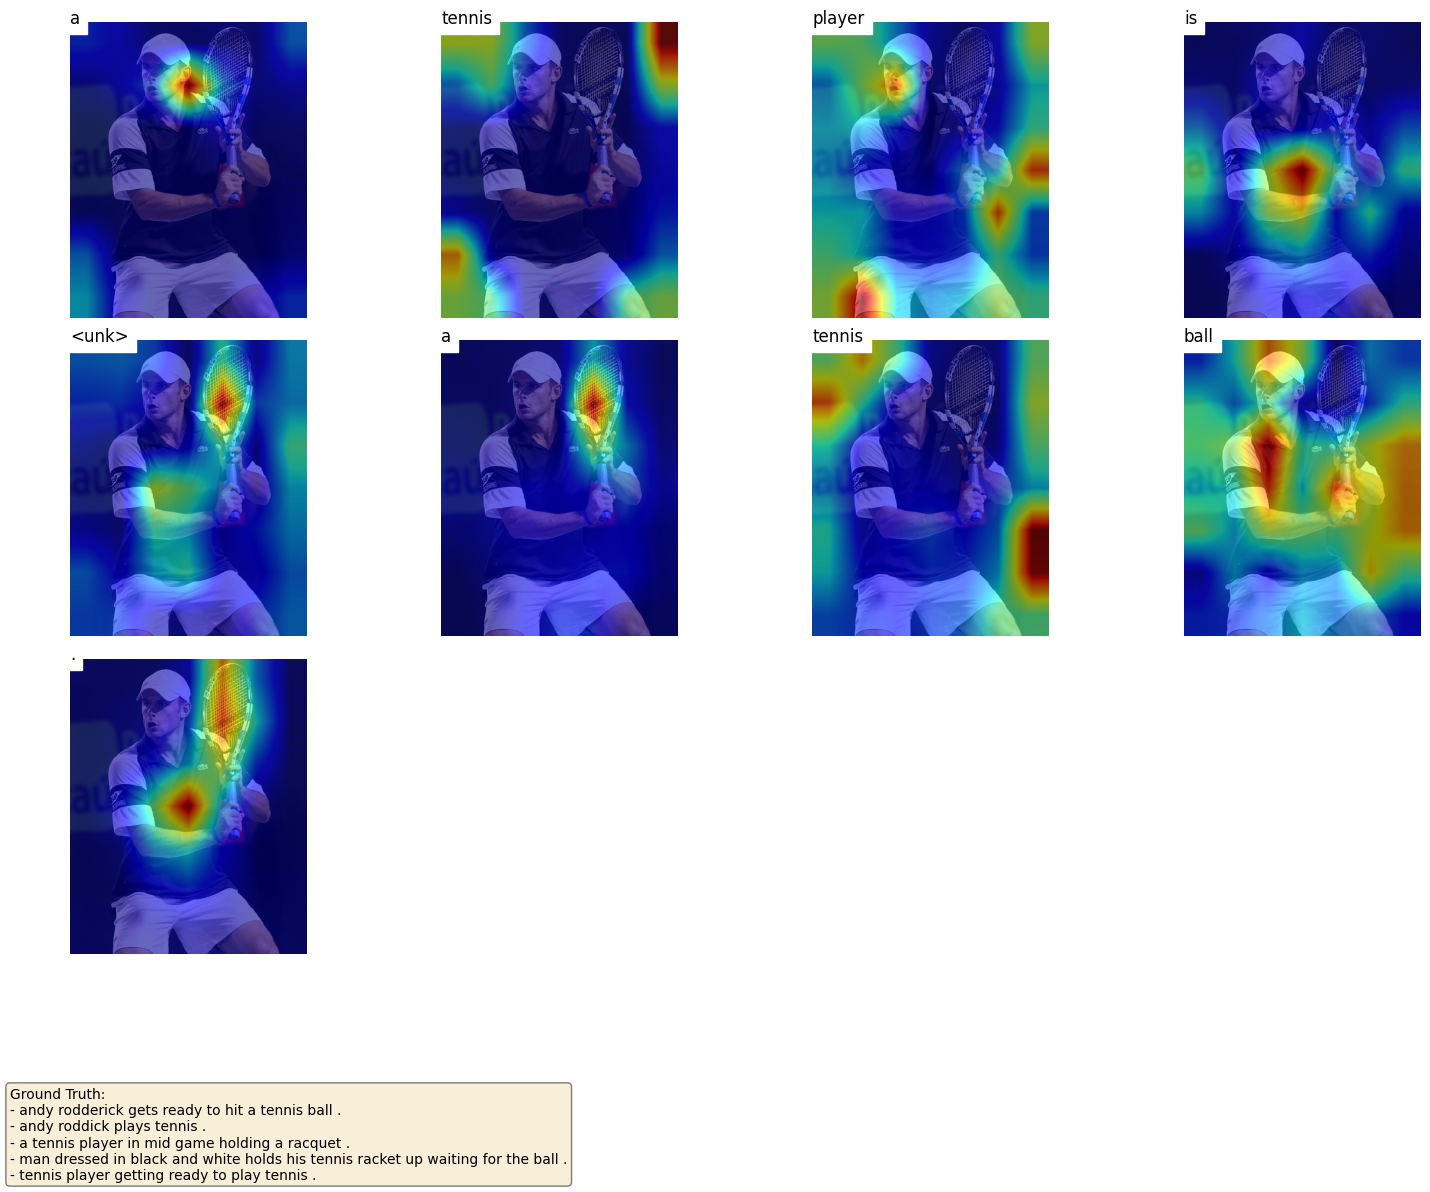

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import cv2

from config import config
from inference import load_model_and_vocab, greedy_decode

def plot_attention(image_path, words, attention_weights, save_path=None, ground_truth=None):
    """
    Vẽ ảnh gốc và bản đồ nhiệt Attention cho từng từ.
    words: list các từ đã dự đoán.
    attention_weights: tensor shape (seq_len, n_heads, 49)
    """
    img = Image.open(image_path).convert("RGB")
    img_array = np.array(img)
    
    # Tính trung bình attention qua các heads
    # shape: (seq_len, 49)
    avg_attention = attention_weights.mean(dim=1)
    
    num_words = len(words)
    cols = 4
    rows = (num_words // cols) + (1 if num_words % cols != 0 else 0)
    
    fig = plt.figure(figsize=(15, 4 * rows))
    
    for i in range(num_words):
        plt.subplot(rows, cols, i + 1)
        plt.text(0, 1, words[i], color='black', backgroundcolor='white', fontsize=12)
        plt.imshow(img_array)
        
        # Resize attention map (7x7) to match image size
        # avg_attention[i] has 49 elements
        attn_map = avg_attention[i].reshape(7, 7).numpy()
        attn_map = cv2.resize(attn_map, (img_array.shape[1], img_array.shape[0]))
        
        plt.imshow(attn_map, alpha=0.6, cmap='jet')
        plt.axis('off')
        
    plt.tight_layout()
    if ground_truth:
        gt_text = "Ground Truth:\n" + "\n".join([f"- {gt}" for gt in ground_truth])
        plt.figtext(0.01, 0.01, gt_text, fontsize=10, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        plt.subplots_adjust(bottom=0.2) # Chừa khoảng trống cho ground truth text

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"XAI result saved to: {save_path}")
    plt.show()

def run_xai_example(image_path, ground_truth=None):
    device = config.DEVICE
    checkpoint_path = os.path.join(config.CHECKPOINT_DIR, "epoch_9.pt")
    data_dir = config.DATA_DIR
    
    model, vocab = load_model_and_vocab(checkpoint_path, data_dir, device)
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    print(f"Bắt đầu phân tích XAI cho ảnh: {image_path}")
    if ground_truth:
        print("Ground Truth Captions:")
        for i, gt in enumerate(ground_truth):
            print(f"  {i+1}. {gt}")

    caption, attention_weights = greedy_decode(model, img_tensor, vocab, device=device, return_attention=True)
    
    print(f"Dự đoán: {caption}")
    
    words = caption.split()
    save_name = f"xai_{os.path.basename(image_path).split('.')[0]}.png"
    save_path = os.path.join(config.EVAL_RESULTS_DIR, save_name)
    
    plot_attention(image_path, words, attention_weights, save_path=save_path, ground_truth=ground_truth)

if __name__ == "__main__":
    # Thay bằng path ảnh thực tế trong folder Images của em
    # Ví dụ chọn 1 ảnh ngẫu nhiên từ tập test hoặc chỉ định 1 ảnh
    import random
    from datasets.preprocessing import load_captions
    captions = load_captions(os.path.join(config.DATA_DIR, "captions.txt"))
    test_img = random.choice(list(captions.keys()))
    image_path = os.path.join(config.DATA_DIR, "Images", test_img)
    gt_caps = captions[test_img]
    
    run_xai_example(image_path, ground_truth=gt_caps)


Mô hình đang tải Vocabulary chuẩn...
Loading existing splits from data\splits_seed_42.json
Đang tải trọng số từ: Checkpoints\epoch_9.pt
Loading existing splits from data_splits\splits_seed_42.json
Đang visualize 5 ảnh từ tập Test...
Đã lưu kết quả visualize tại: evaluation_results\test_visualization_118.png


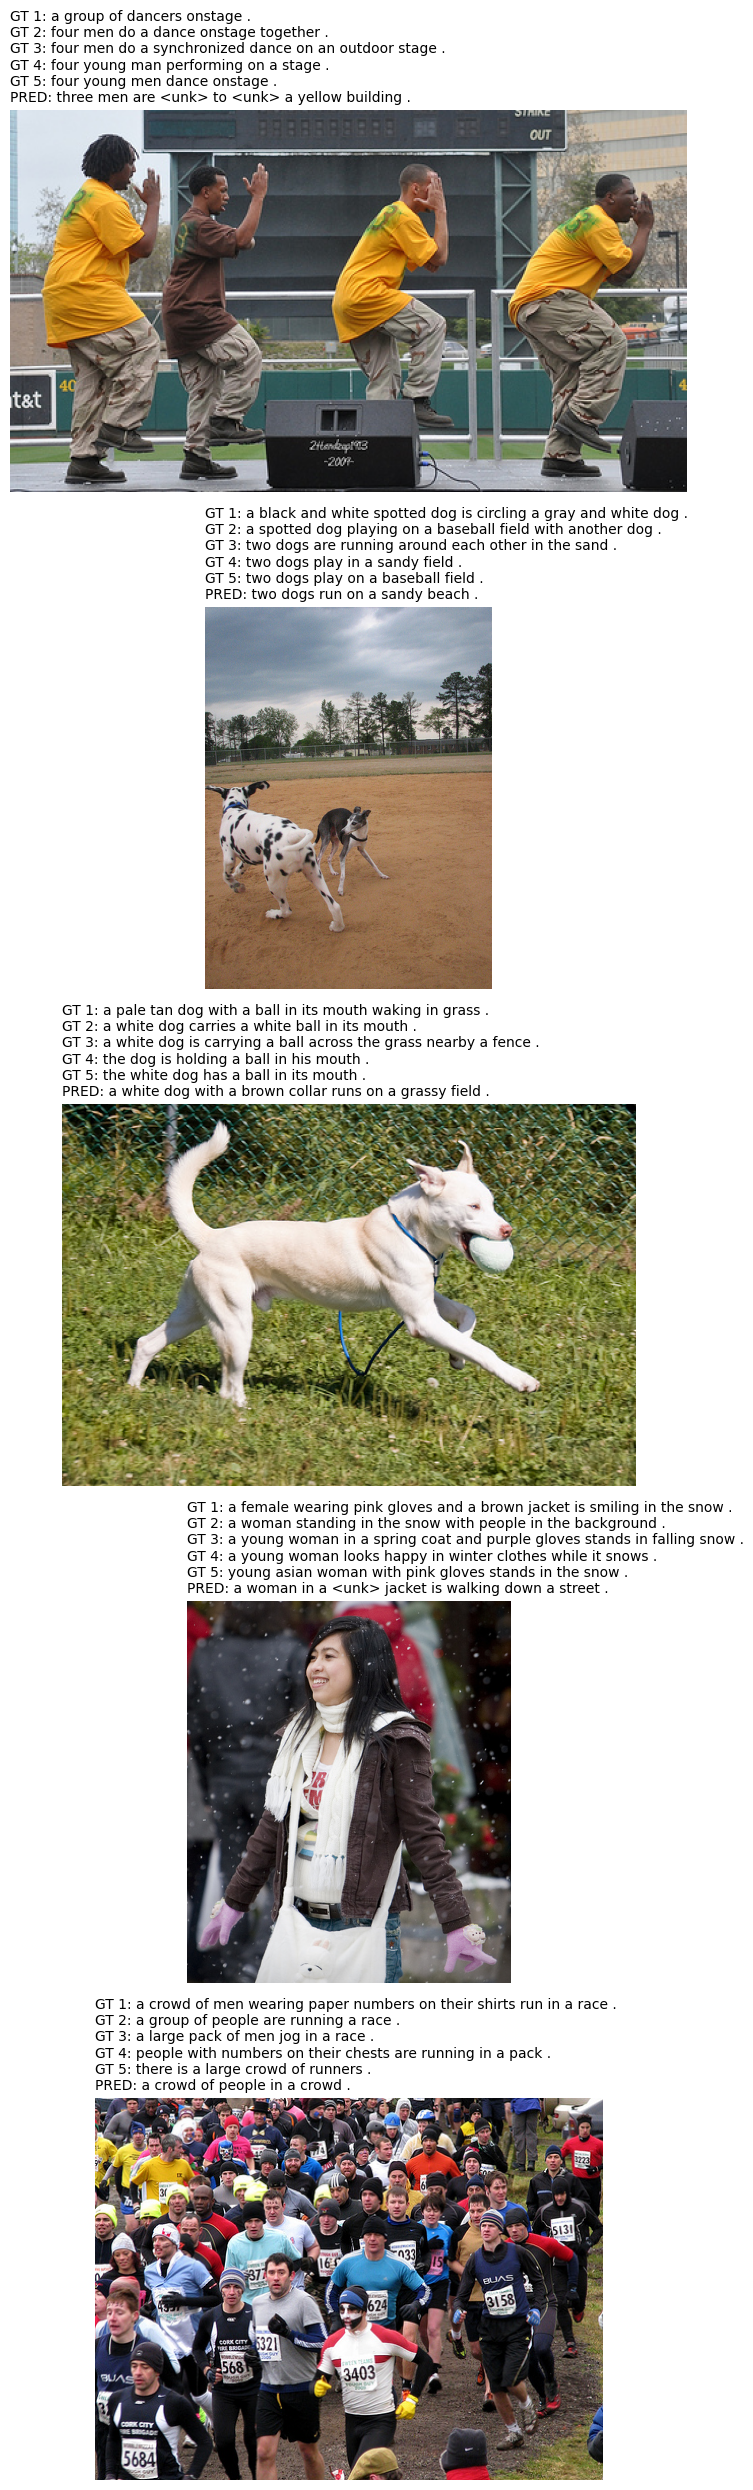

In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import random
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

from config import config
from inference import load_model_and_vocab, greedy_decode
from datasets.data_loader import get_loaders
from datasets.preprocessing import load_captions

def visualize_test_results(num_samples=5, save_to_dir=None):
    device = config.DEVICE
    checkpoint_path = os.path.join(config.CHECKPOINT_DIR, "epoch_9.pt")
    data_dir = config.DATA_DIR
    
    # 1. Load Model & Vocab
    model, vocab = load_model_and_vocab(checkpoint_path, data_dir, device)
    model.eval()

    # 2. Lấy Test Set chuẩn
    (train_loader, val_loader, test_loader), _, _ = get_loaders(
        data_dir,
        split_dir=config.SPLIT_DIR,
        train_split=config.TRAIN_SPLIT,
        val_split=config.VAL_SPLIT,
        test_split=config.TEST_SPLIT,
        seed=config.SEED,
        vocab=vocab
    )
    
    test_dataset = test_loader.dataset
    all_captions = load_captions(os.path.join(data_dir, "captions.txt"))
    
    # 3. Chọn ngẫu nhiên các ảnh duy nhất từ tập test
    # Lưu ý: dataset phẳng hóa nên 1 ảnh có thể xuất hiện nhiều lần
    unique_img_paths = list(set(test_dataset.image_paths))
    samples = random.sample(unique_img_paths, min(num_samples, len(unique_img_paths)))

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    if save_to_dir is None:
        save_to_dir = config.EVAL_RESULTS_DIR
    os.makedirs(save_to_dir, exist_ok=True)

    print(f"Đang visualize {len(samples)} ảnh từ tập Test...")
    
    plt.figure(figsize=(20, 5 * len(samples)))
    
    for i, img_path in enumerate(samples):
        img_name = os.path.basename(img_path)
        img_pil = Image.open(img_path).convert("RGB")
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        # Dự đoán
        with torch.no_grad():
            pred_caption = greedy_decode(model, img_tensor, vocab, device=device)

        # Ground Truth
        gt_captions = all_captions.get(img_name, ["No GT found"])
        
        # Plot
        plt.subplot(len(samples), 1, i + 1)
        plt.imshow(img_pil)
        
        gt_text = "\n".join([f"GT {j+1}: {cap}" for j, cap in enumerate(gt_captions)])
        title = f"{gt_text}\nPRED: {pred_caption}"
        plt.title(title, fontsize=10, loc='left')
        plt.axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_to_dir, f"test_visualization_{random.randint(100,999)}.png")
    plt.savefig(save_path)
    print(f"Đã lưu kết quả visualize tại: {save_path}")
    # plt.show() # Tạm tắt nếu chạy trong môi trường không UI

if __name__ == "__main__":
    visualize_test_results(num_samples=5)
